<div style="display:flex;align-items:center"><img src="recursos/logos/upc.png" width="230"><img src="recursos/logos/caixabank.png" width="155" style="margin-left:20px"><span style="margin-left:auto;text-align:right"><b>CaixaBank · Advanced Analytics Program</b><br>Python profesional para analítica avanzada</span></div>

# Programación eficiente para analítica

**Duración:** 1,5 horas · **Caso:** recálculo del histórico de operaciones

## El nuevo límite

El informe mensual ya es correcto y está optimizado. El equipo debe recalcular varios años de histórico: ya no basta con mejorar una línea de Pandas; hay que decidir cómo ejecutar el trabajo sin cambiar el contrato del informe.

> Eficiencia significa obtener una salida validada con un consumo de tiempo, memoria y complejidad operativa proporcionales al volumen.

## Objetivos

- Medir una referencia y comparar alternativas sin asumir que una librería siempre gana.
- Usar un generador y `chunksize` para limitar la materialización.
- Aplicar NumPy a un cálculo numérico por bloque.
- Validar un pipeline combinado: Python estándar + Pandas + NumPy.
- Contrastar la misma transformación con Polars lazy.
- Reconocer casos concretos para Numba y `ThreadPoolExecutor`.

**Contrato del informe:** importe neto y número de operaciones confirmadas por mes, región y canal.

# Parte guiada — comparar técnicas sobre el mismo contrato

## 1. Preparación y utilidades de medición

Medimos varias repeticiones y mostramos la mediana. `tracemalloc` observa asignaciones Python; para DataFrames, lo acompañamos de mediciones propias del tamaño de los objetos. Ninguna métrica aislada describe toda la memoria del proceso.

In [20]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import time
import tracemalloc

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='deep')
RNG = np.random.default_rng(42)
RUTA_HISTORICO = Path('datos_simulados') / 'historico_operaciones.csv'
RUTA_HISTORICO.parent.mkdir(exist_ok=True)

def medir(nombre, funcion, repeticiones=3):
    """Devuelve resultado y evidencia temporal; no sustituye un profiler."""
    tiempos, picos = [], []
    resultado = None
    for _ in range(repeticiones):
        tracemalloc.start()
        inicio = time.perf_counter()
        resultado = funcion()
        tiempos.append((time.perf_counter() - inicio) * 1_000)
        _, pico = tracemalloc.get_traced_memory()
        picos.append(pico / 1e6)
        tracemalloc.stop()
    return resultado, {'tecnica': nombre, 'mediana_ms': np.median(tiempos), 'pico_trazado_mb': np.median(picos)}

def graficar_medidas(medidas, titulo):
    tabla = pd.DataFrame(medidas)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    sns.barplot(data=tabla, x='tecnica', y='mediana_ms', ax=axes[0], color='#0066a6')
    sns.barplot(data=tabla, x='tecnica', y='pico_trazado_mb', ax=axes[1], color='#00a3a3')
    axes[0].set(title=titulo, ylabel='Mediana (ms)', xlabel='')
    axes[1].set(title='Asignaciones trazadas', ylabel='MB', xlabel='')
    plt.tight_layout()
    return tabla

def crear_historico(ruta, filas=240_000, semilla=42):
    rng = np.random.default_rng(semilla)
    datos = pd.DataFrame({
        'fecha': pd.Timestamp('2022-01-01') + pd.to_timedelta(rng.integers(0, 1_095, filas), unit='D'),
        'region': rng.choice(['norte', 'sur', 'este', 'oeste'], filas),
        'canal': rng.choice(['oficina', 'web', 'app'], filas, p=[.25, .30, .45]),
        'estado': rng.choice(['confirmada', 'rechazada'], filas, p=[.91, .09]),
        'importe': rng.gamma(2.2, 85, filas).round(2),
        'referencia_externa': [f'REF-{i:07d}' for i in range(filas)],
        'comentario_carga': rng.choice(['ok', 'revisar', ''], filas),
    })
    datos.to_csv(ruta, index=False)

if not RUTA_HISTORICO.exists():
    crear_historico(RUTA_HISTORICO)
print(f'Archivo reproducible: {RUTA_HISTORICO.stat().st_size / 1e6:.1f} MB')

Archivo reproducible: 13.1 MB


### Qué estamos midiendo — y qué no

La mediana resume varias ejecuciones del mismo experimento. `tracemalloc` mide asignaciones Python, **no el pico total de RAM**; por eso no la interpretaremos como la memoria absoluta de Pandas, NumPy o Polars. Añadimos también el tamaño profundo del DataFrame de salida cuando existe. Para producción harían falta profiling y métricas del proceso, no solo esta celda.

In [21]:
def memoria_dataframe_mb(datos):
    """Tamaño profundo del DataFrame devuelto; no representa el pico del proceso."""
    return datos.memory_usage(deep=True).sum() / 1e6 if isinstance(datos, pd.DataFrame) else np.nan

def medir(nombre, funcion, repeticiones=3):
    """Evidencia comparable de tiempo y asignaciones; no sustituye un profiler."""
    tiempos, picos = [], []
    resultado = None
    for _ in range(repeticiones):
        tracemalloc.start()
        inicio = time.perf_counter()
        resultado = funcion()
        tiempos.append((time.perf_counter() - inicio) * 1_000)
        _, pico = tracemalloc.get_traced_memory()
        picos.append(pico / 1e6)
        tracemalloc.stop()
    return resultado, {
        'tecnica': nombre,
        'mediana_ms': np.median(tiempos),
        'pico_trazado_mb': np.median(picos),
        'resultado_mb': memoria_dataframe_mb(resultado),
    }

def graficar_medidas(medidas, titulo):
    tabla = pd.DataFrame(medidas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
    fig.suptitle(titulo, x=0.02, ha='left', fontsize=14, fontweight='bold')
    sns.barplot(data=tabla, x='tecnica', y='mediana_ms', ax=axes[0], color='#0066a6')
    sns.barplot(data=tabla, x='tecnica', y='pico_trazado_mb', ax=axes[1], color='#00a3a3')
    axes[0].set(title='Tiempo de ejecución', ylabel='Mediana (ms)', xlabel='')
    axes[1].set(title='Asignaciones trazadas', ylabel='Pico trazado (MB)', xlabel='')
    for eje in axes:
        eje.tick_params(axis='x', labelrotation=18, labelsize=9)
        for etiqueta in eje.get_xticklabels():
            etiqueta.set_horizontalalignment('right')
        eje.margins(x=0.12)
    plt.show()
    return tabla

## 2. Referencia Pandas: fijar primero la salida correcta

Esta versión carga el origen completo. Es deliberadamente sencilla porque funciona como oráculo de validación; no es la solución para un histórico que supera la RAM.

In [22]:
COLUMNAS = ['fecha', 'region', 'canal', 'estado', 'importe']
CLAVES = ['mes', 'region', 'canal']

def aplicar_comision_numpy(importes, canales):
    """App tiene 0,10 %; oficina/web, 0,20 %. Devuelve un ndarray."""
    tasas = np.where(canales == 'app', 0.001, 0.002)
    return importes * (1 - tasas)

def informe_completo(ruta):
    datos = pd.read_csv(ruta, usecols=COLUMNAS, parse_dates=['fecha'])
    datos = datos.loc[datos['estado'].eq('confirmada'), ['fecha', 'region', 'canal', 'importe']].copy()
    datos['importe_neto'] = aplicar_comision_numpy(datos['importe'].to_numpy(), datos['canal'].to_numpy())
    datos['mes'] = datos['fecha'].dt.to_period('M').astype(str)
    return (datos.groupby(CLAVES, as_index=False)
            .agg(importe_neto=('importe_neto', 'sum'), operaciones=('importe_neto', 'size'))
            .sort_values(CLAVES, ignore_index=True))

referencia, medida_completa = medir('Pandas completo', lambda: informe_completo(RUTA_HISTORICO))
referencia.head()

,mes,region,canal,importe_neto,operaciones
0,2022-01,este,app,125542.33200,679
1,2022-01,este,oficina,74423.62446,400
2,2022-01,este,web,85289.56902,424
3,2022-01,norte,app,127043.03979,682
4,2022-01,norte,oficina,76252.33970,400


## 3. Pandas: medir el coste de procesar por bloques

Primero aislamos la decisión de lectura: mantenemos Pandas y la misma regla de negocio, pero leemos por bloques. Así podemos comparar **carga completa frente a chunks** antes de incorporar generadores explícitos o NumPy.

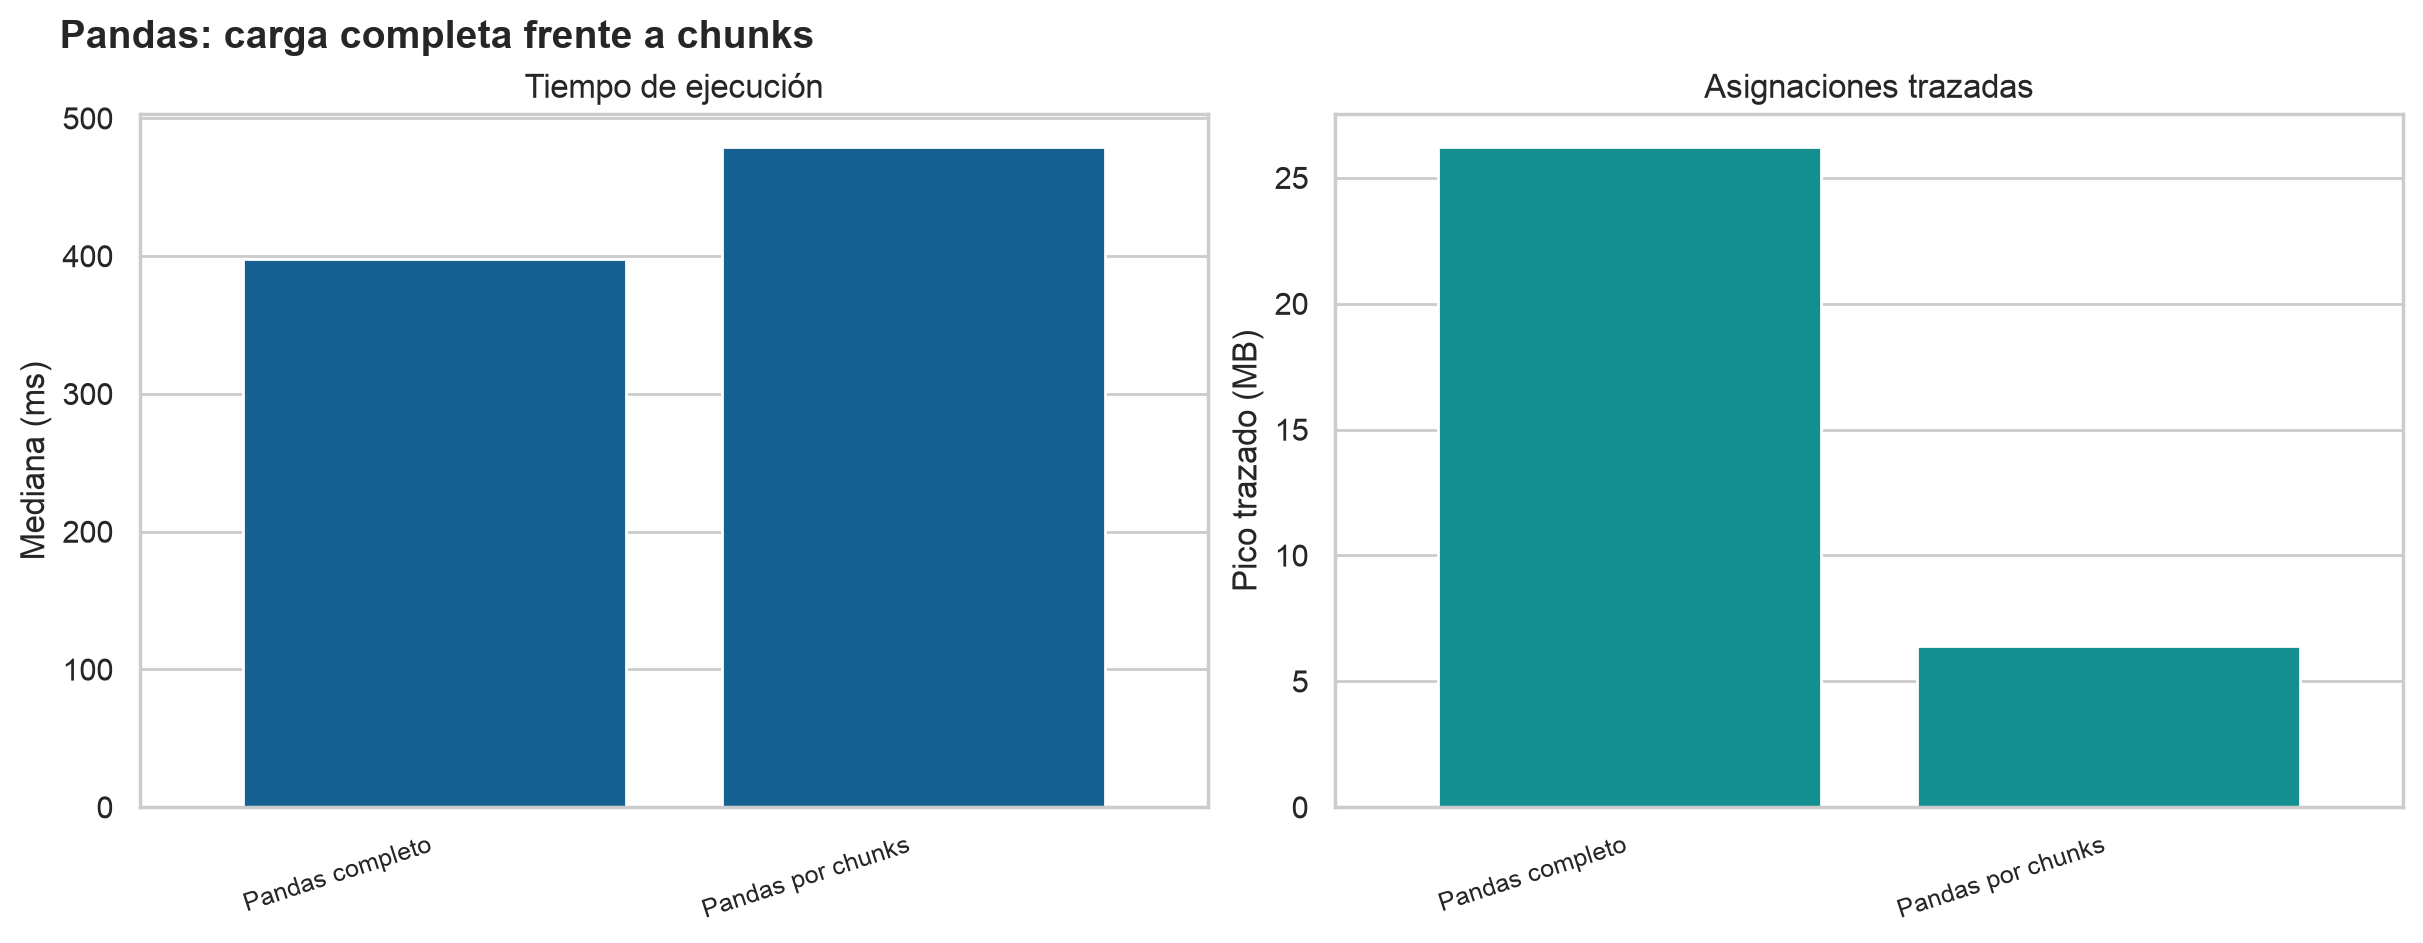

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,Pandas completo,397.590542,26.204915,0.024306
1,Pandas por chunks,478.813416,6.398961,0.024306


In [23]:
def bloques_pandas(ruta, chunksize=40_000):
    """Iterador de Pandas: cada bloque se reduce antes de leer el siguiente."""
    lector = pd.read_csv(ruta, usecols=COLUMNAS, parse_dates=['fecha'], chunksize=chunksize)
    for bloque in lector:
        utiles = bloque.loc[bloque['estado'].eq('confirmada'), ['fecha', 'region', 'canal', 'importe']].copy()
        factor = utiles['canal'].map({'app': 0.999}).fillna(0.998)
        utiles['importe_neto'] = utiles['importe'] * factor
        utiles['mes'] = utiles['fecha'].dt.to_period('M').astype(str)
        yield (utiles.groupby(CLAVES, as_index=False)
               .agg(importe_neto=('importe_neto', 'sum'), operaciones=('importe_neto', 'size')))

def informe_chunks_pandas(ruta, chunksize=40_000):
    parciales = list(bloques_pandas(ruta, chunksize=chunksize))
    combinado = pd.concat(parciales, ignore_index=True)
    return (combinado.groupby(CLAVES, as_index=False)
            .agg(importe_neto=('importe_neto', 'sum'), operaciones=('operaciones', 'sum'))
            .sort_values(CLAVES, ignore_index=True))

resultado_chunks_pandas, medida_chunks_pandas = medir('Pandas por chunks', lambda: informe_chunks_pandas(RUTA_HISTORICO))
pd.testing.assert_frame_equal(referencia, resultado_chunks_pandas, check_exact=False, rtol=1e-10)
graficar_medidas([medida_completa, medida_chunks_pandas], 'Pandas: carga completa frente a chunks')

**Interpretación.** No esperamos necesariamente que chunks sea más rápido: si el archivo cabe en RAM, el coste de leer y combinar varios bloques puede empeorar el tiempo. La evidencia relevante es que el pipeline mantiene una memoria de trabajo acotada cuando el histórico deja de caber. Por eso la decisión depende de la restricción, no de una cifra aislada.

## 4. Python estándar + Pandas: un generador de bloques reducidos

El `for` no recibe un DataFrame completo. `bloques_reducidos` produce un resumen parcial por vez y el consumidor decide cuándo pedir el siguiente. Esta separación evita conservar bloques que ya no necesitamos.

In [24]:
def bloques_reducidos(ruta, chunksize=40_000):
    """Generador: lee, filtra y reduce un bloque antes de continuar."""
    lector = pd.read_csv(ruta, usecols=COLUMNAS, parse_dates=['fecha'], chunksize=chunksize)
    for bloque in lector:
        utiles = bloque.loc[bloque['estado'].eq('confirmada'), ['fecha', 'region', 'canal', 'importe']].copy()
        utiles['importe_neto'] = aplicar_comision_numpy(utiles['importe'].to_numpy(), utiles['canal'].to_numpy())
        utiles['mes'] = utiles['fecha'].dt.to_period('M').astype(str)
        yield (utiles.groupby(CLAVES, as_index=False)
               .agg(importe_neto=('importe_neto', 'sum'), operaciones=('importe_neto', 'size')))

primer_parcial = next(bloques_reducidos(RUTA_HISTORICO))
primer_parcial.head()

,mes,region,canal,importe_neto,operaciones
0,2022-01,este,app,22228.05969,120
1,2022-01,este,oficina,11109.58630,59
2,2022-01,este,web,12479.81036,64
3,2022-01,norte,app,24979.60539,133
4,2022-01,norte,oficina,13969.44512,76


## 5. Pipeline combinado: combinar suficiente estado, no bloques enteros

Para una suma y un conteo, cada parcial puede combinarse asociativamente. La media se calcularía al final como `suma_total / conteo_total`; nunca como media de medias. La gráfica compara ahora el pipeline combinado con la versión por chunks de Pandas: así aislamos el efecto de introducir NumPy en cada bloque.

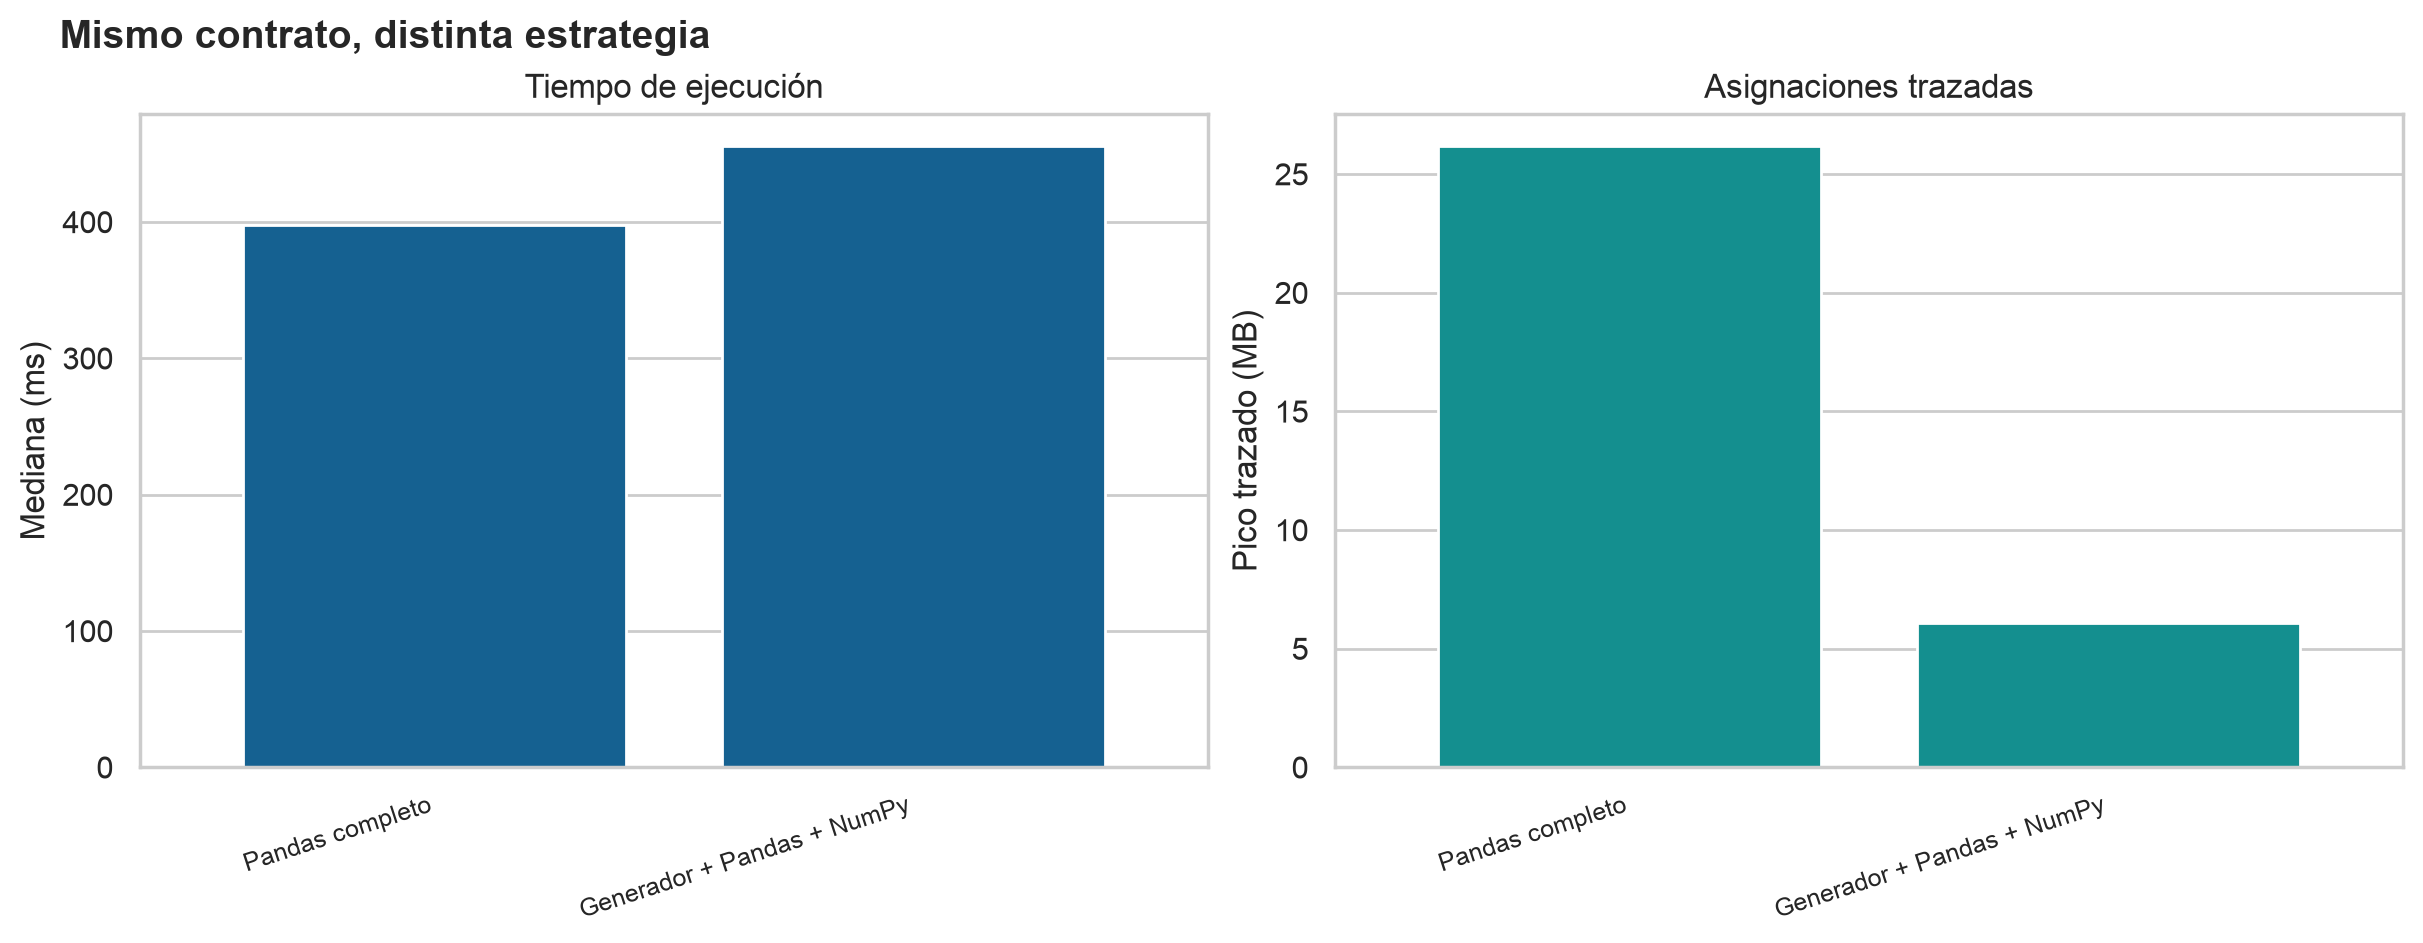

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,Pandas completo,397.590542,26.204915,0.024306
1,Generador + Pandas + NumPy,456.068375,6.105562,0.024306


In [25]:
def informe_chunks_numpy(ruta, chunksize=40_000):
    parciales = list(bloques_reducidos(ruta, chunksize=chunksize))
    combinado = pd.concat(parciales, ignore_index=True)
    return (combinado.groupby(CLAVES, as_index=False)
            .agg(importe_neto=('importe_neto', 'sum'), operaciones=('operaciones', 'sum'))
            .sort_values(CLAVES, ignore_index=True))

resultado_combinado, medida_combinada = medir('Generador + Pandas + NumPy', lambda: informe_chunks_numpy(RUTA_HISTORICO))
pd.testing.assert_frame_equal(referencia, resultado_combinado, check_exact=False, rtol=1e-10)
graficar_medidas([medida_completa, medida_combinada], 'Mismo contrato, distinta estrategia')

### Comparación aislada: chunks de Pandas frente al pipeline combinado

Ambas versiones procesan el mismo CSV por bloques y validan el mismo contrato. La diferencia es el cálculo de comisión dentro de cada bloque. Esta comparación es más útil que atribuir todo el cambio a una única librería.

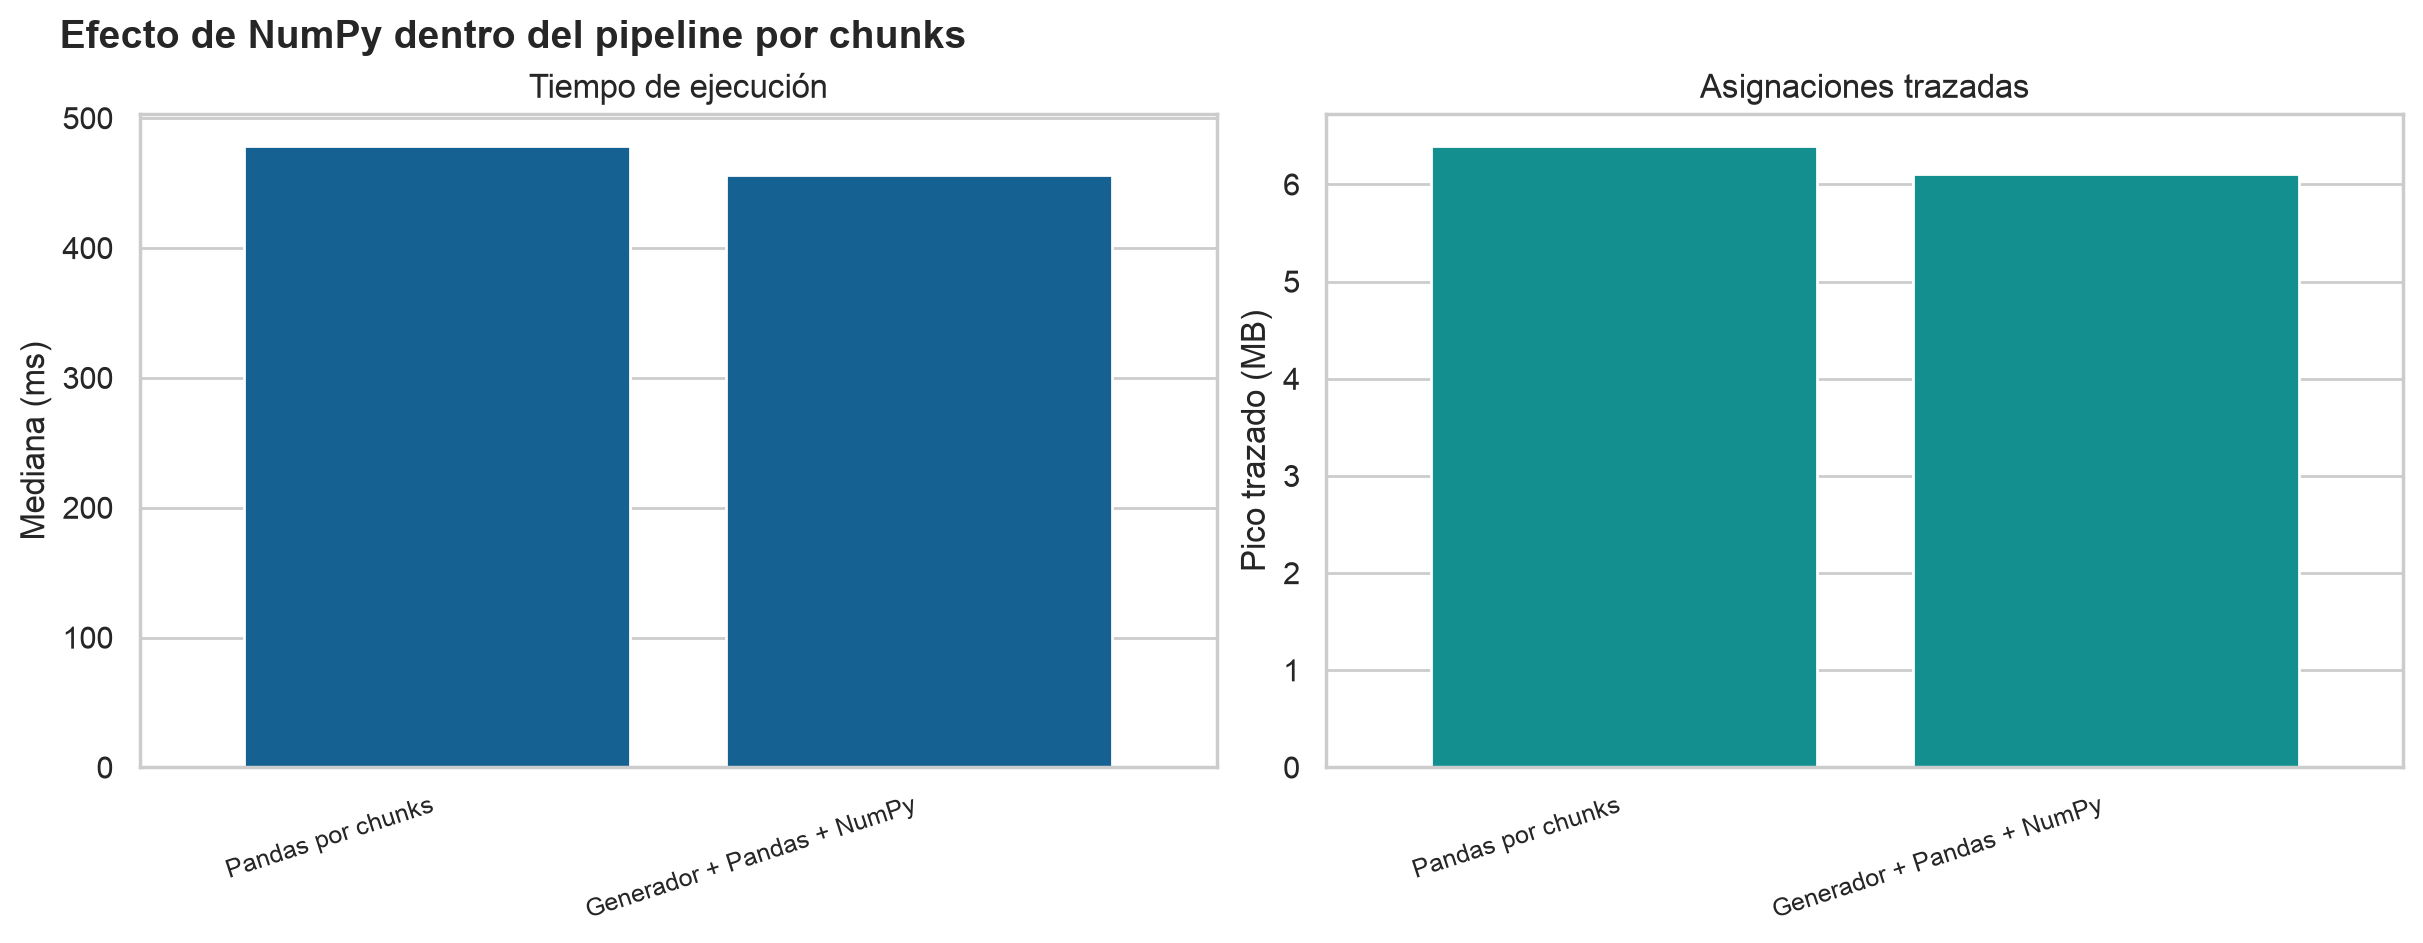

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,Pandas por chunks,478.813416,6.398961,0.024306
1,Generador + Pandas + NumPy,456.068375,6.105562,0.024306


In [26]:
graficar_medidas(
    [medida_chunks_pandas, medida_combinada],
    'Efecto de NumPy dentro del pipeline por chunks',
)

## 6. NumPy: cuándo un cálculo vectorizado evita un bucle Python

La comisión se calcula sobre arrays. Comparamos una implementación explícita de referencia con la expresión vectorizada; ambas deben coincidir antes de interpretar el tiempo.

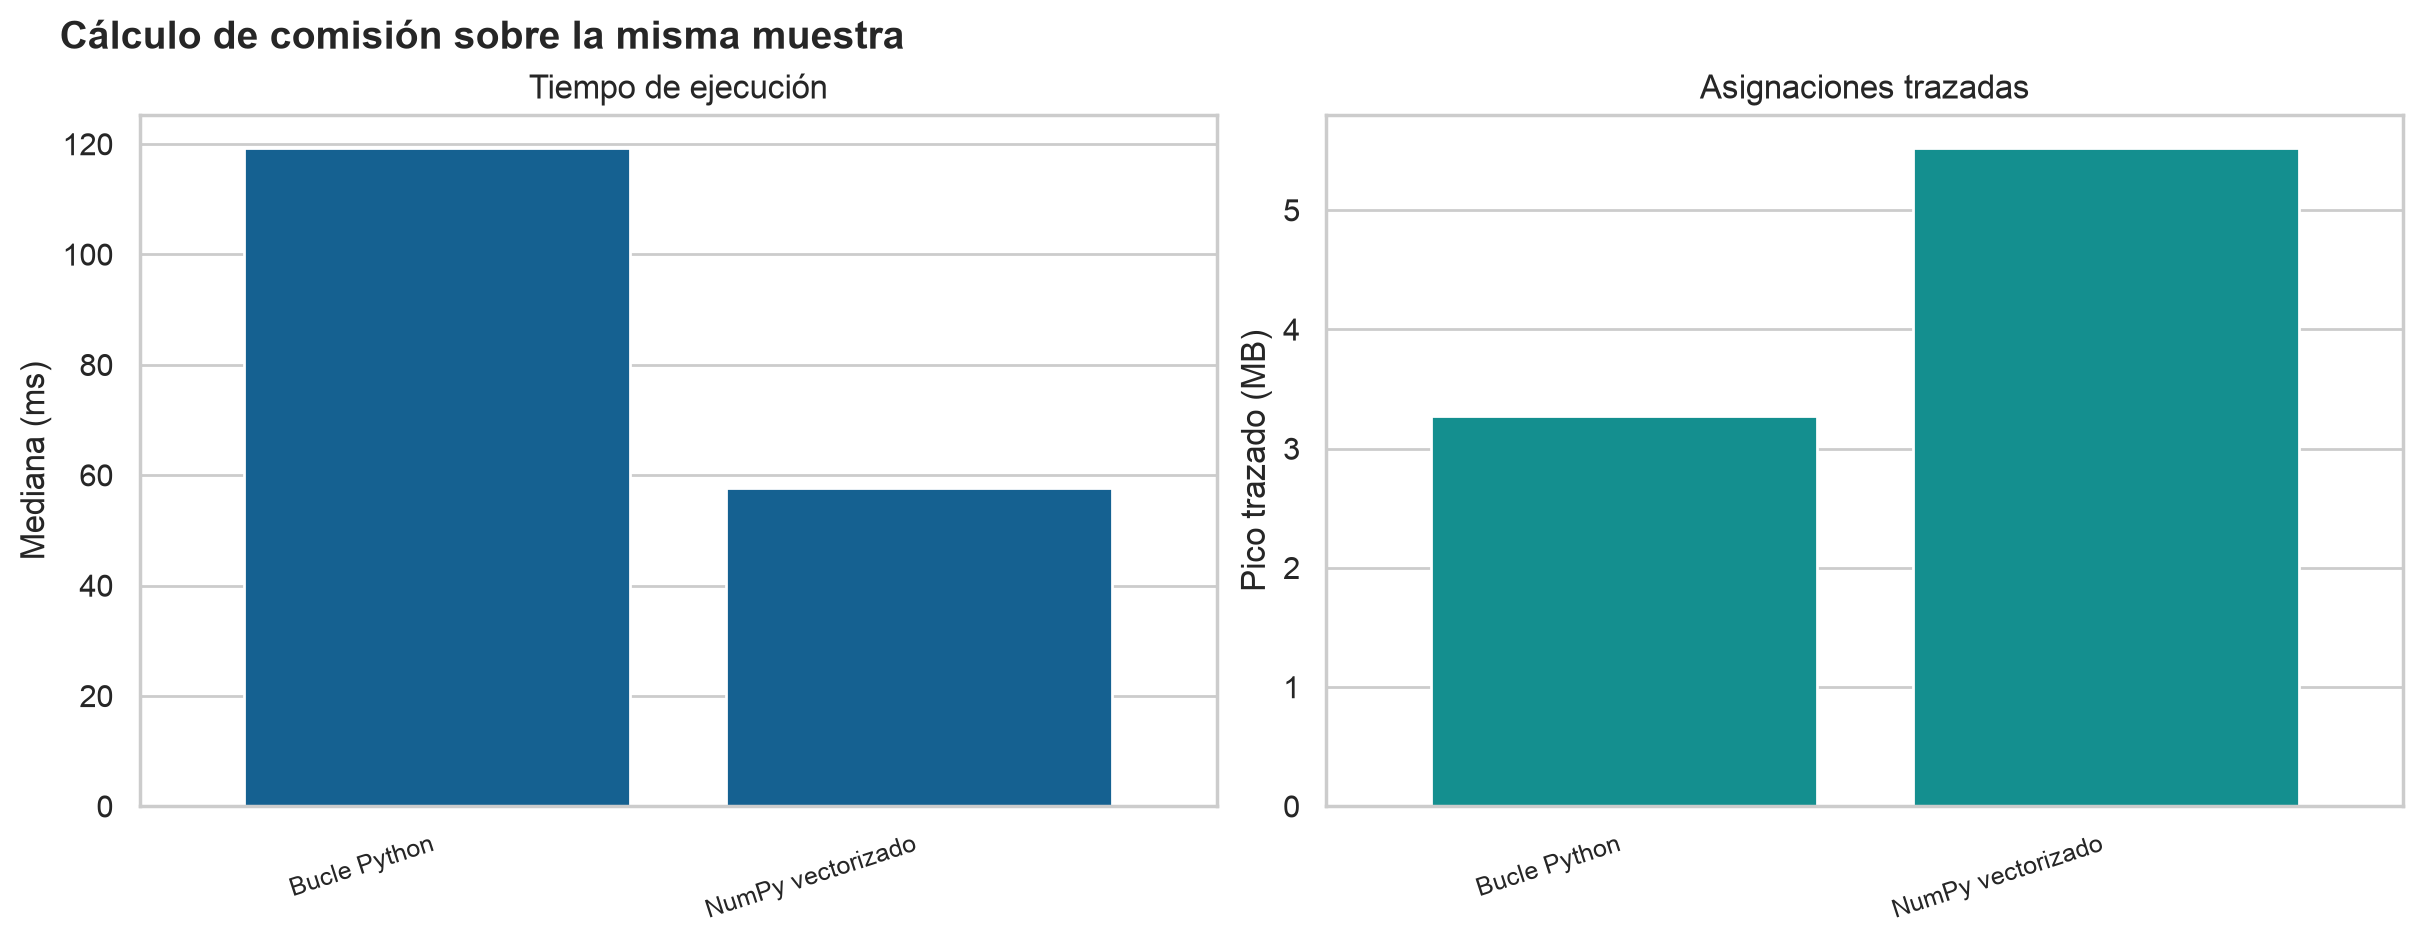

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,Bucle Python,119.280916,3.271434,NaN
1,NumPy vectorizado,57.638750,5.521125,NaN


In [27]:
muestra = pd.read_csv(RUTA_HISTORICO, usecols=['importe', 'canal'], nrows=80_000)

def comision_python(importes, canales):
    salida = []
    for importe, canal in zip(importes, canales):
        tasa = 0.001 if canal == 'app' else 0.002
        salida.append(importe * (1 - tasa))
    return np.asarray(salida)

python_neto, medida_python = medir('Bucle Python', lambda: comision_python(muestra['importe'], muestra['canal']))
numpy_neto, medida_numpy = medir('NumPy vectorizado', lambda: aplicar_comision_numpy(muestra['importe'].to_numpy(), muestra['canal'].to_numpy()))
assert np.allclose(python_neto, numpy_neto)
graficar_medidas([medida_python, medida_numpy], 'Cálculo de comisión sobre la misma muestra')

## 7. Polars: expresar el mismo informe como un plan lazy

La alternativa no se adopta por sintaxis. Comprobamos que conserva el contrato de Pandas y observamos el plan optimizado. La celda queda protegida si Polars no está instalado.

SORT BY [col("mes"), col("region"), col("canal")]
  AGGREGATE[maintain_order: false]
    [col("importe_neto").sum(), len().alias("operaciones")] BY [col("mes"), col("region"), col("canal")]
    FROM
    simple π 4/4 ["mes", "region", "canal", ... 1 other column]
       WITH_COLUMNS:
       [col("fecha").str.strptime(["raise"]).dt.to_string().alias("mes"), (col("importe") * when(col("canal") == "app").then(dyn float: 0.999).otherwise(dyn float: 0.998).cast(Float64)).alias("importe_neto")] 
        simple π 4/4 ["fecha", "region", "canal", ... 1 other column]
          Csv SCAN [datos_simulados/historico_operaciones.csv]
          PROJECT 5/7 COLUMNS
          SELECTION: col("estado") == "confirmada"
          ESTIMATED ROWS: 230679


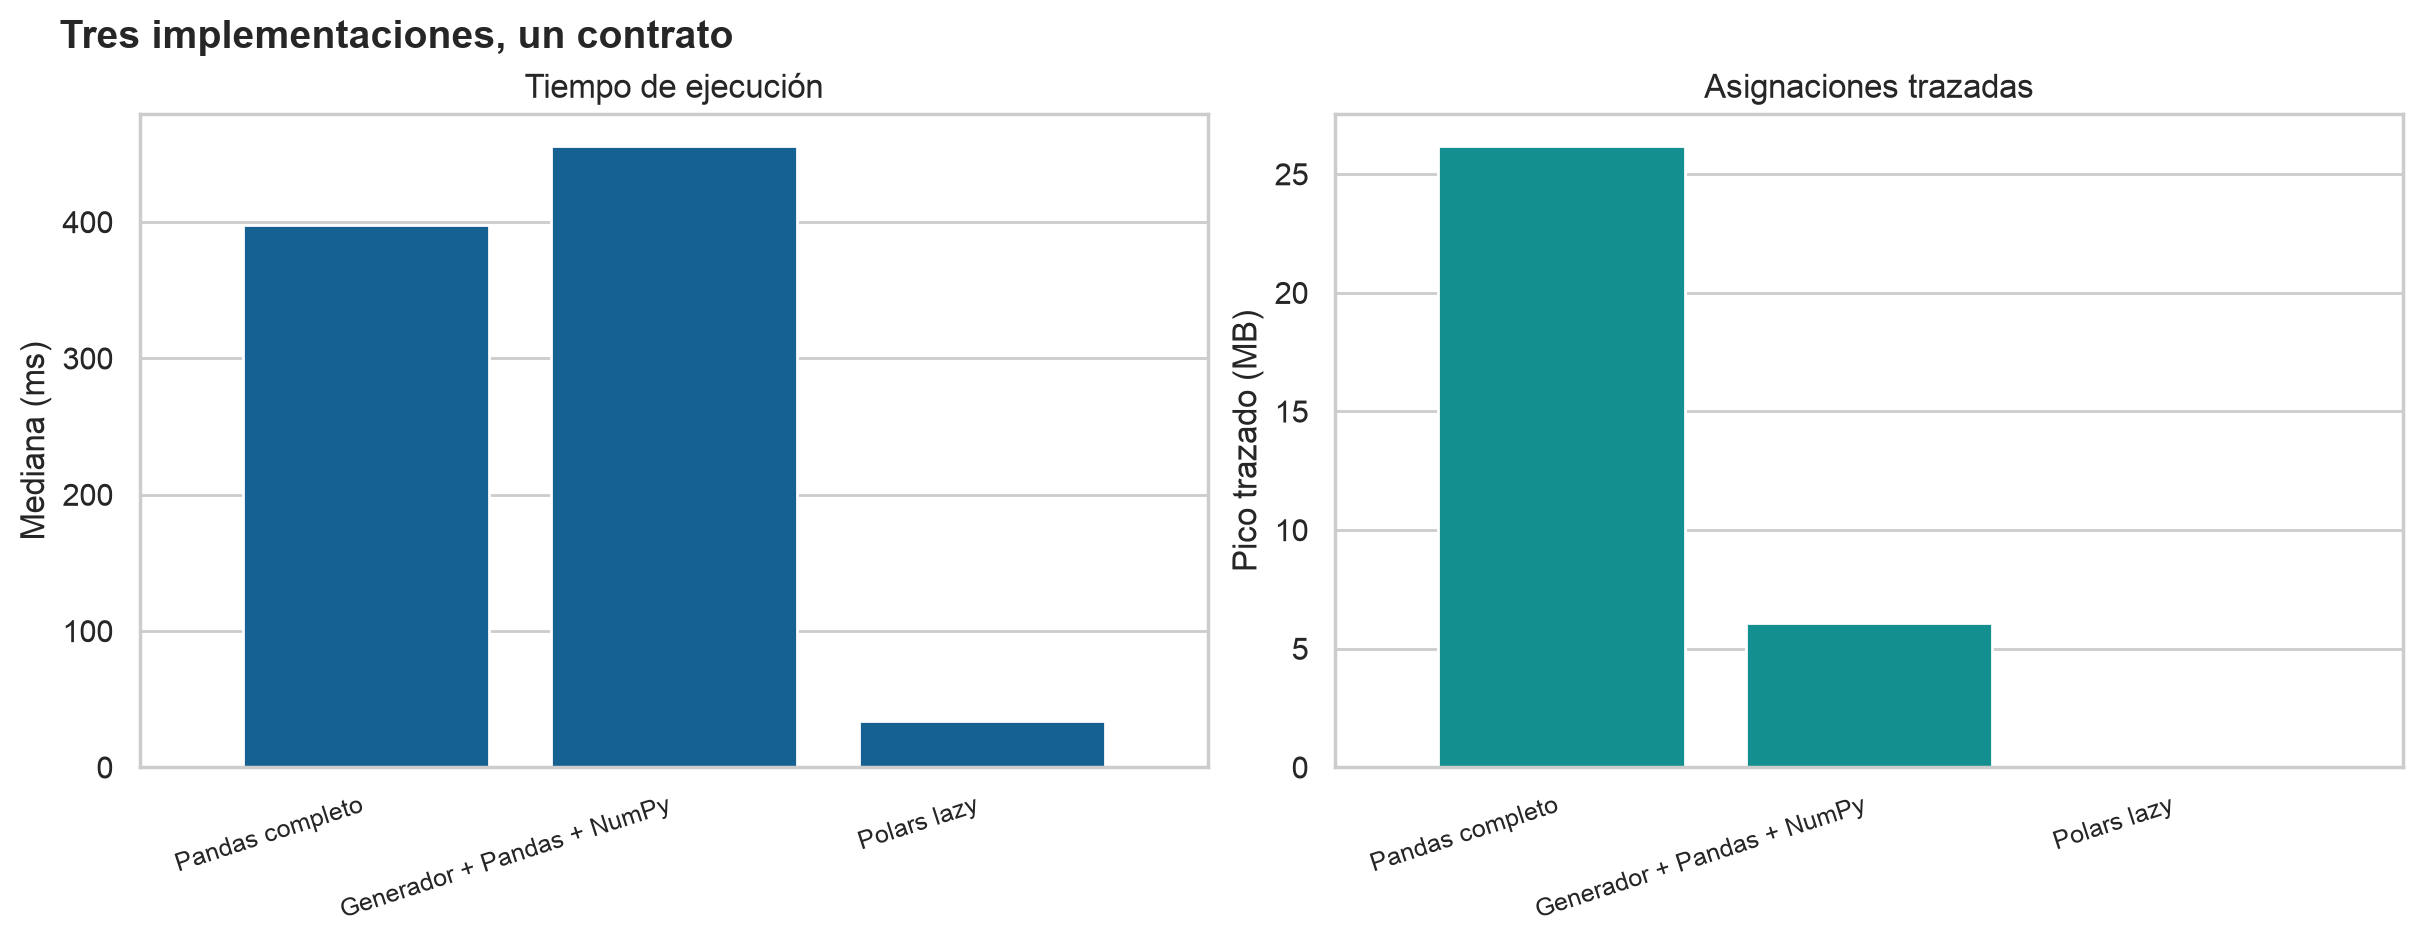

In [28]:
try:
    import polars as pl
    POLARS_DISPONIBLE = True
except ImportError:
    POLARS_DISPONIBLE = False
    print('Polars no está instalado. Extensión opcional: pip install polars')

if POLARS_DISPONIBLE:
    plan_lazy = (pl.scan_csv(RUTA_HISTORICO)
        .select(COLUMNAS)
        .filter(pl.col('estado') == 'confirmada')
        .with_columns([
            pl.col('fecha').str.strptime(pl.Date, strict=False).dt.strftime('%Y-%m').alias('mes'),
            (pl.col('importe') * pl.when(pl.col('canal') == 'app').then(0.999).otherwise(0.998)).alias('importe_neto'),
        ])
        .group_by(CLAVES)
        .agg([pl.col('importe_neto').sum().alias('importe_neto'), pl.len().alias('operaciones')])
        .sort(CLAVES))
    resultado_polars, medida_polars = medir('Polars lazy', lambda: plan_lazy.collect().to_pandas())
    pd.testing.assert_frame_equal(referencia, resultado_polars, check_dtype=False, check_exact=False, rtol=1e-10)
    print(plan_lazy.explain(optimized=True))
    graficar_medidas([medida_completa, medida_combinada, medida_polars], 'Tres implementaciones, un contrato')

## 8. Antes de acelerar: identificar qué limita el programa

Una técnica solo tiene sentido si ataca la **restricción dominante**. En un mismo pipeline puede haber varias, pero no conviene resolverlas todas a la vez.

| Tipo | El cuello de botella es… | Ejemplos | Estrategia típica |
|---|---|---|---|
| Memoria | Los datos o intermedios no caben cómodamente en RAM. | Histórico CSV, joins o copias grandes. | Seleccionar pronto; generadores, chunks o Polars lazy. |
| I/O-bound | El proceso pasa la mayor parte del tiempo esperando. | API, red, disco remoto. | `ThreadPoolExecutor`, con límites y manejo de errores. |
| CPU-bound numérico | El cálculo domina y opera sobre arrays numéricos. | Simulación, señales, reglas acumulativas. | NumPy; Numba si el bucle es necesario. |
| CPU-bound independiente | Varias tareas grandes no comparten estado. | Procesar ficheros o modelos separados. | Procesos, solo si el overhead queda compensado. |

> **Criterio:** primero medimos y validamos una alternativa sencilla; solo después añadimos concurrencia o compilación.

## 9. Dos técnicas especializadas: Numba y threads

No forman parte del pipeline combinado porque resuelven restricciones distintas. Numba es útil para una regla numérica secuencial; los threads solo para esperas de I/O independientes. Los ejemplos siguientes no demuestran que sean mejores para todo el pipeline: demuestran dónde encajan.

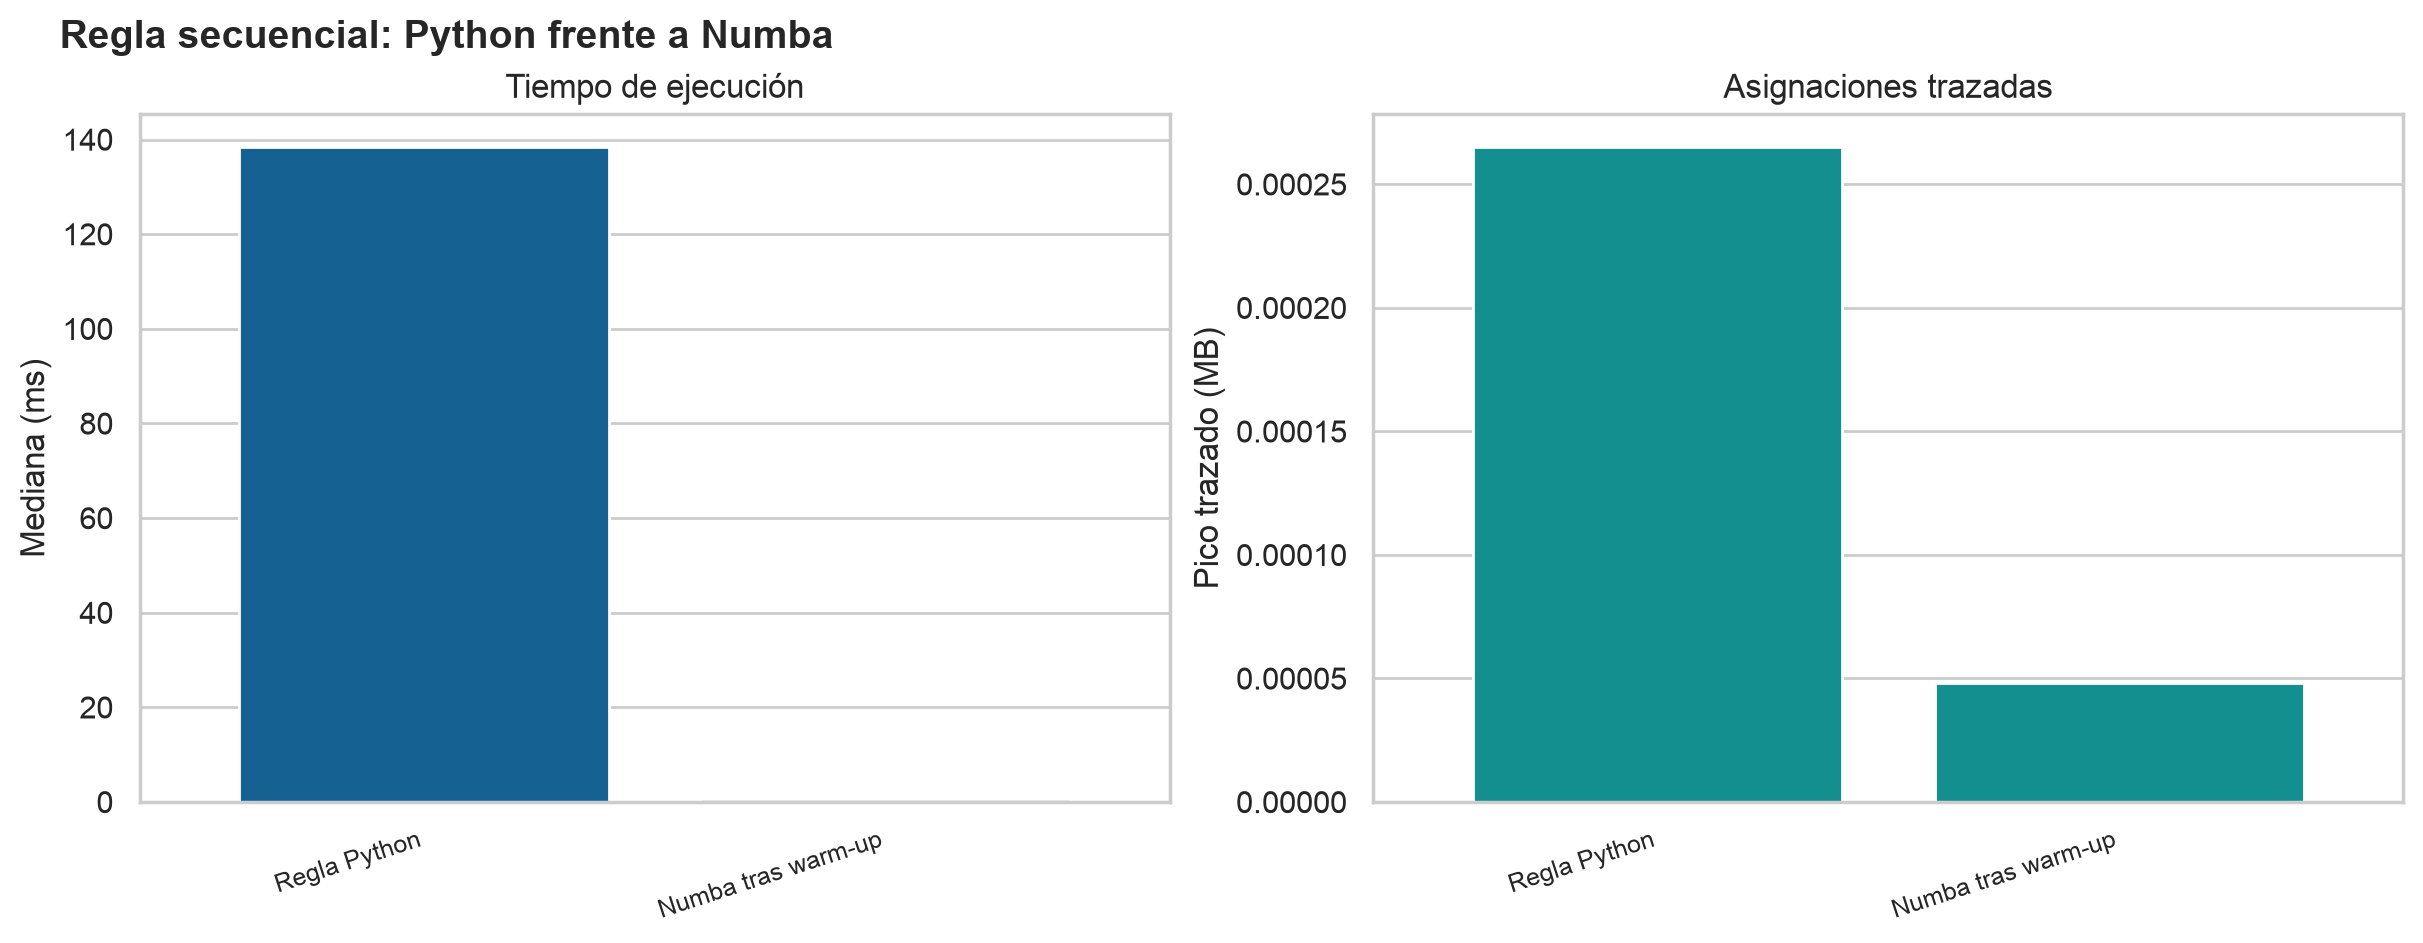

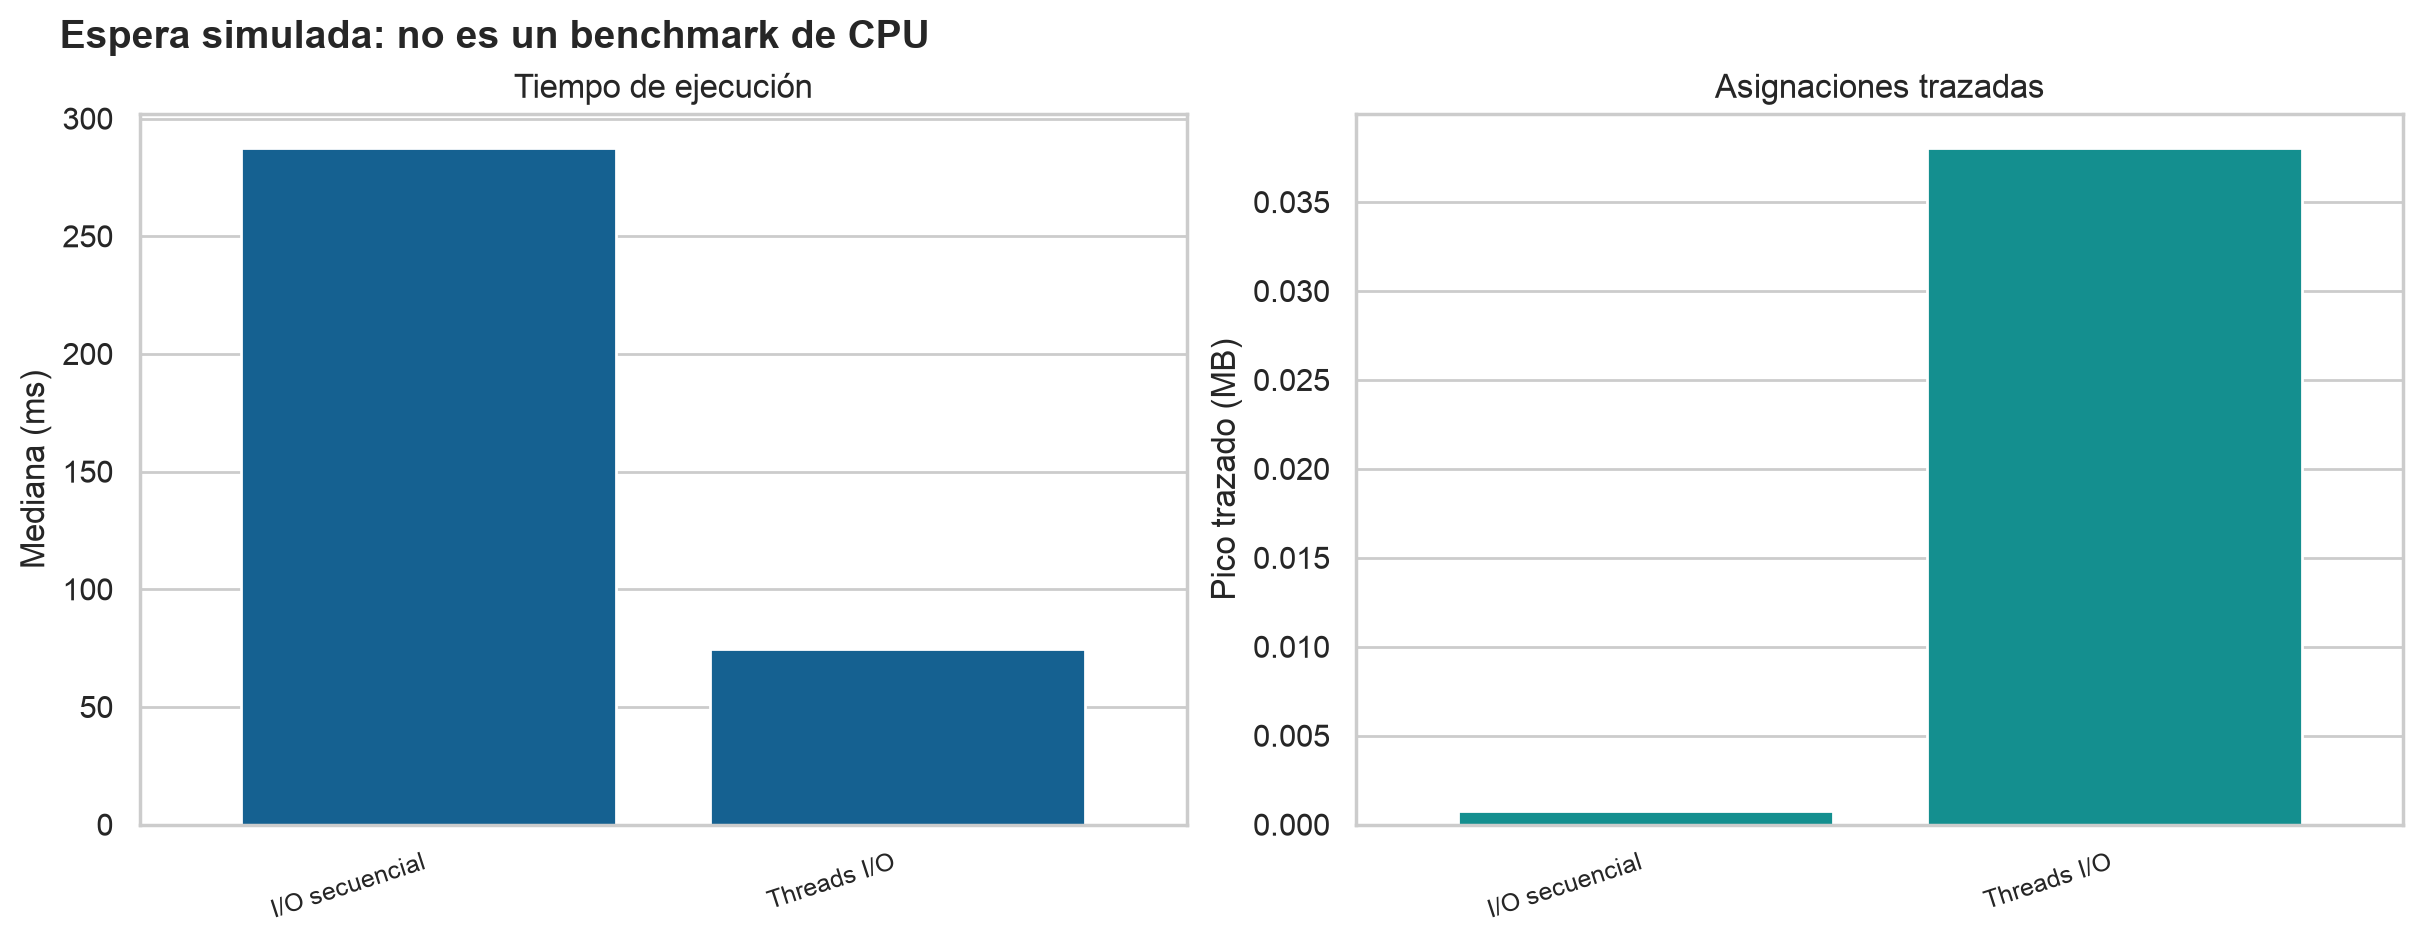

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,I/O secuencial,287.336125,0.000779,NaN
1,Threads I/O,74.604687,0.038017,NaN


In [29]:
def alertas_python(valores, umbral=250.0):
    acumulado, alertas = 0.0, 0
    for valor in valores:
        acumulado += valor
        if acumulado > umbral:
            alertas += 1
            acumulado = 0.0
    return alertas

try:
    from numba import njit
    vector = RNG.gamma(2.0, 20.0, 400_000).astype(np.float64)
    alertas_numba = njit(alertas_python)
    _ = alertas_numba(vector[:10])  # warm-up: fuera del benchmark
    salida_numba, medida_numba = medir('Numba tras warm-up', lambda: alertas_numba(vector))
    salida_python, medida_alertas_python = medir('Regla Python', lambda: alertas_python(vector))
    assert salida_numba == salida_python
    graficar_medidas([medida_alertas_python, medida_numba], 'Regla secuencial: Python frente a Numba')
except ImportError:
    print('Numba no está instalado; conservar el ejemplo como extensión.')

def consulta_simulada(i):
    time.sleep(0.02)
    return i * 2

_, medida_io_secuencial = medir('I/O secuencial', lambda: [consulta_simulada(i) for i in range(12)], repeticiones=2)
_, medida_io_threads = medir('Threads I/O', lambda: list(ThreadPoolExecutor(max_workers=4).map(consulta_simulada, range(12))), repeticiones=2)
graficar_medidas([medida_io_secuencial, medida_io_threads], 'Espera simulada: no es un benchmark de CPU')

# Práctica — experimentar sin perder el contrato

Los ejercicios 1–4 forman el recorrido principal. Los ejercicios 5–7 son extensiones para quien avance más rápido o para cerrar en discusión colectiva. En todos los casos: medir, validar y explicar la decisión.

## Ejercicio 1 — Generador de bloques útiles

**Situación.** Quieres que las etapas posteriores nunca reciban columnas que no pertenecen al informe.

**Tarea.** Implementa `bloques_confirmados`: debe leer por `chunksize`, seleccionar `COLUMNAS`, filtrar confirmadas y hacer `yield` de cada DataFrame reducido.

**Entrega.** Muestra el primer bloque y comprueba que no incluye `estado`, `referencia_externa` ni `comentario_carga`.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 1</strong></summary>

~~~python
def bloques_confirmados(ruta, chunksize=30_000):
    # pd.read_csv puede devolver un iterador si recibe chunksize.
    lector = pd.read_csv(ruta, usecols=COLUMNAS, parse_dates=['fecha'], chunksize=chunksize)
    for bloque in lector:
        confirmadas = bloque['estado'].eq('confirmada')
        # Decide qué cuatro columnas necesita el siguiente paso.
        # Aplica el filtro y entrega ese DataFrame con yield.
        yield ...
~~~
</details>

## Ejercicio 2 — NumPy dentro de cada bloque

**Situación.** La regla de comisión debe aplicarse antes de agrupar, sin usar `apply(axis=1)`.

**Tarea.** Añade `importe_neto` a `primer_bloque` usando `aplicar_comision_numpy`. Mide ese cálculo y valida una observación de canal `app`.

**Entrega.** El DataFrame con la nueva columna y una fila de evidencia temporal.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 2</strong></summary>

~~~python
def calcular_neto_bloque(datos):
    salida = datos.copy()
    importes = salida['importe'].to_numpy()
    canales = salida['canal'].to_numpy()
    # La función guiada recibe primero los importes y después los canales.
    salida['importe_neto'] = ...
    return salida

# Pasa la función completa a medir mediante una lambda.
~~~
</details>

## Ejercicio 3 — Resumen parcial combinable

**Situación.** Un bloque procesado no puede guardarse entero.

**Tarea.** Implementa `resumir_bloque` sobre la salida del ejercicio 2: crea `mes` y devuelve suma de `importe_neto` y conteo por `CLAVES`.

**Entrega.** Un resumen parcial con menos filas que el bloque de entrada.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 3</strong></summary>

~~~python
def resumir_bloque(datos):
    salida = calcular_neto_bloque(datos).copy()
    salida['mes'] = salida['fecha'].dt.to_period('M').astype(str)
    agrupado = salida.groupby(CLAVES, as_index=False)
    # ¿Qué operación resume importes? ¿Cuál cuenta operaciones?
    return agrupado.agg(...)
~~~
</details>

## Ejercicio 4 — Pipeline combinado y validación

**Situación.** El informe anual debe unir Python estándar, Pandas y NumPy sin perder el contrato.

**Tarea.** Implementa `informe_practica` usando `bloques_confirmados`, `resumir_bloque`, `pd.concat` de parciales y una agregación final. Mídelo y compáralo con `referencia`.

**Entrega.** Tabla de métricas y `assert_frame_equal` que se ejecute sin error.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 4</strong></summary>

~~~python
def informe_practica(ruta, chunksize=30_000):
    parciales = []
    for bloque in bloques_confirmados(ruta, chunksize):
        parciales.append(resumir_bloque(bloque))
    combinado = pd.concat(parciales, ignore_index=True)
    # Vuelve a agrupar por CLAVES: hay una fila parcial por cada chunk.
    return ...

# Mide, ordena y compara con referencia después de completar la función.
~~~
</details>

## Ejercicio 5 — Polars lazy con la misma regla

**Situación.** El equipo considera una alternativa lazy.

**Tarea.** Si Polars está disponible, completa un plan para `region == 'norte'`, aplicando filtro, comisión y agregación. Mide `collect()` y valida contra la referencia Pandas filtrada.

**Entrega.** Plan optimizado y comparación de resultados.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 5</strong></summary>

~~~python
plan_norte = (pl.scan_csv(RUTA_HISTORICO)
    # 1. Selecciona las columnas del contrato.
    # 2. Filtra confirmadas y región norte antes de agrupar.
    # 3. Reutiliza la expresión de comisión del caso guiado.
    ...
)

# Materializa solo al final y contrasta contra referencia_norte.
~~~
</details>

## Ejercicio 6 — Numba: medir después del warm-up

**Situación.** Una regla acumulativa no se expresa de forma clara con una única operación vectorizada.

**Tarea.** Si Numba está disponible, compila `alertas_python`, ejecuta un warm-up con un vector pequeño y compara la mediana con Python. Valida que ambos devuelven el mismo número de alertas.

**Entrega.** Dos medidas y una frase sobre por qué la primera llamada no entra en la comparación.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 6</strong></summary>

~~~python
from numba import njit
# Compila la función de referencia y llámala primero con un vector corto.
alertas_compilada = ...
_ = ...(vector[:10])  # warm-up fuera del benchmark

# Mide ambas funciones sobre vector y compara sus salidas.
~~~
</details>

## Ejercicio 7 — Threads solo para I/O

**Situación.** Debes recuperar 12 indicadores de una API; el trabajo local es mínimo, pero cada llamada espera 20 ms.

**Tarea.** Mide `consulta_simulada` en secuencial y con `ThreadPoolExecutor(max_workers=4)`. Comprueba que los resultados son iguales y calcula el speedup.

**Entrega.** Una recomendación que explique por qué esta técnica no se usaría para `alertas_python`.

<details><summary><strong>Obtener pista de ayuda para el ejercicio 7</strong></summary>

~~~python
valores = range(12)
# Primero define una función secuencial que devuelva una lista.
# Después usa ThreadPoolExecutor(max_workers=4) y executor.map.
# Mide ambas, verifica igualdad y divide los tiempos para obtener speedup.
~~~
</details>

# Soluciones de la práctica

Los enunciados y ayudas anteriores se mantienen para poder comparar tu aproximación con una posible solución. Las decisiones técnicas se justifican junto a la evidencia, no por el nombre de la librería.

In [30]:
# Ejercicio 1
def bloques_confirmados(ruta, chunksize=30_000):
    lector = pd.read_csv(ruta, usecols=COLUMNAS, parse_dates=['fecha'], chunksize=chunksize)
    for bloque in lector:
        utiles = bloque.loc[bloque['estado'].eq('confirmada'), ['fecha', 'region', 'canal', 'importe']].copy()
        yield utiles

primer_bloque = next(bloques_confirmados(RUTA_HISTORICO))
assert 'estado' not in primer_bloque.columns
primer_bloque.head()

,fecha,region,canal,importe
0,2022-04-08,sur,app,444.24
1,2024-04-27,este,app,108.22
2,2023-12-18,sur,web,104.60
3,2023-04-26,este,app,189.20
4,2023-04-20,sur,app,94.37


In [31]:
# Ejercicio 2
def calcular_neto_bloque(datos):
    salida = datos.copy()
    salida['importe_neto'] = aplicar_comision_numpy(salida['importe'].to_numpy(), salida['canal'].to_numpy())
    return salida

con_neto, medida_neto = medir('NumPy en un bloque', lambda: calcular_neto_bloque(primer_bloque))
app = con_neto.loc[con_neto['canal'].eq('app')].iloc[0]
assert np.isclose(app['importe_neto'], app['importe'] * 0.999)
pd.DataFrame([medida_neto])

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,NumPy en un bloque,22.491,2.549227,1.542318


In [32]:
# Ejercicio 3
def resumir_bloque(datos):
    salida = calcular_neto_bloque(datos).copy()
    salida['mes'] = salida['fecha'].dt.to_period('M').astype(str)
    return (salida.groupby(CLAVES, as_index=False)
            .agg(importe_neto=('importe_neto', 'sum'), operaciones=('importe_neto', 'size')))

parcial = resumir_bloque(primer_bloque)
assert len(parcial) < len(primer_bloque)
parcial.head()

,mes,region,canal,importe_neto,operaciones
0,2022-01,este,app,17962.51950,96
1,2022-01,este,oficina,9307.45778,46
2,2022-01,este,web,10127.76388,49
3,2022-01,norte,app,17287.38531,88
4,2022-01,norte,oficina,10591.70414,57


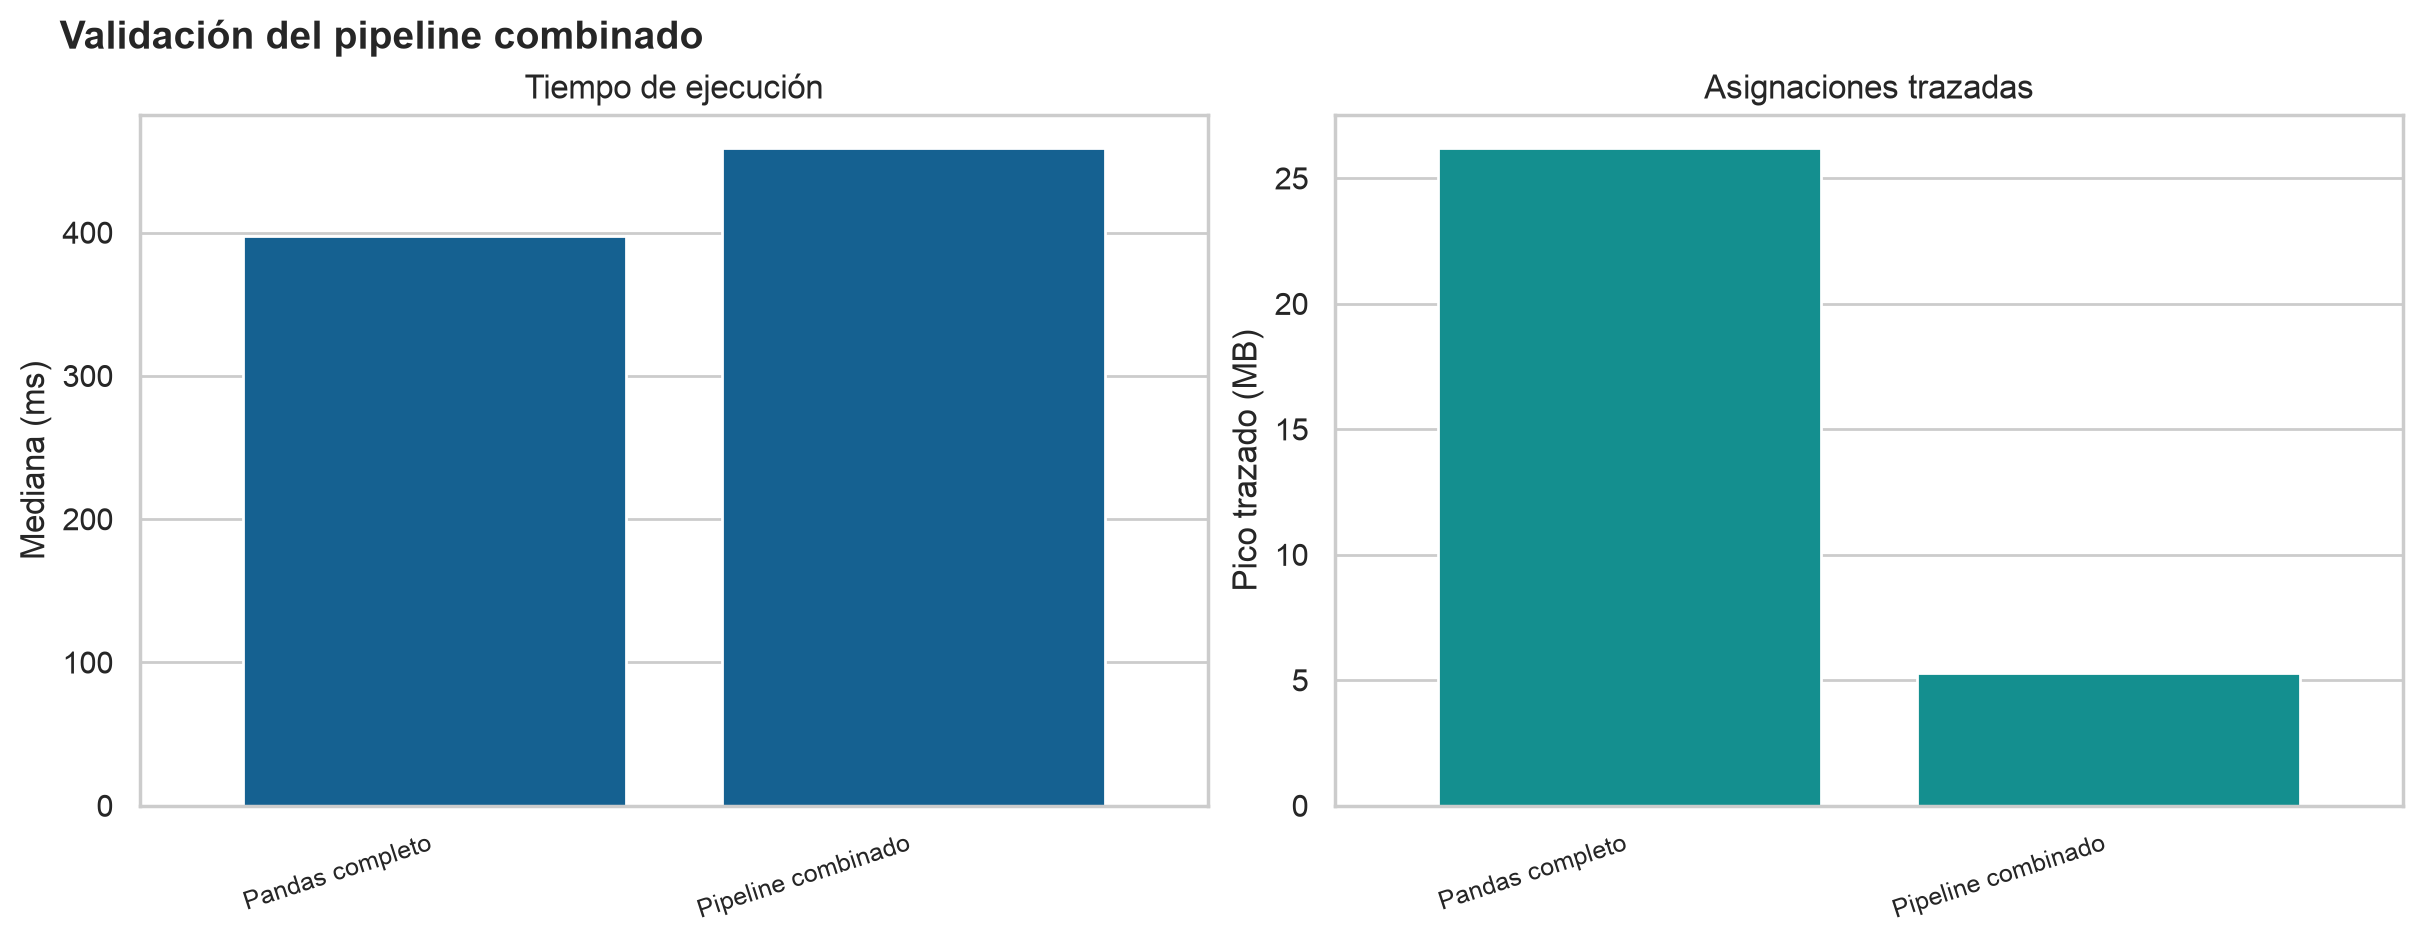

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb
0,Pandas completo,397.590542,26.204915,0.024306
1,Pipeline combinado,458.979791,5.269843,0.024306


In [33]:
# Ejercicio 4
def informe_practica(ruta, chunksize=30_000):
    parciales = [resumir_bloque(bloque) for bloque in bloques_confirmados(ruta, chunksize)]
    combinado = pd.concat(parciales, ignore_index=True)
    return (combinado.groupby(CLAVES, as_index=False)
            .agg(importe_neto=('importe_neto', 'sum'), operaciones=('operaciones', 'sum'))
            .sort_values(CLAVES, ignore_index=True))

resultado_practica, medida_practica = medir('Pipeline combinado', lambda: informe_practica(RUTA_HISTORICO))
pd.testing.assert_frame_equal(referencia, resultado_practica, check_exact=False, rtol=1e-10)
graficar_medidas([medida_completa, medida_practica], 'Validación del pipeline combinado')

SORT BY [col("mes"), col("region"), col("canal")]
  AGGREGATE[maintain_order: false]
    [col("importe_neto").sum(), len().alias("operaciones")] BY [col("mes"), col("region"), col("canal")]
    FROM
    simple π 4/4 ["mes", "region", "canal", ... 1 other column]
       WITH_COLUMNS:
       [col("fecha").str.strptime(["raise"]).dt.to_string().alias("mes"), (col("importe") * when(col("canal") == "app").then(dyn float: 0.999).otherwise(dyn float: 0.998).cast(Float64)).alias("importe_neto")] 
        simple π 4/4 ["fecha", "region", "canal", ... 1 other column]
          Csv SCAN [datos_simulados/historico_operaciones.csv]
          PROJECT 5/7 COLUMNS
          SELECTION: (col("estado") == "confirmada") & (col("region") == "norte")
          ESTIMATED ROWS: 230679


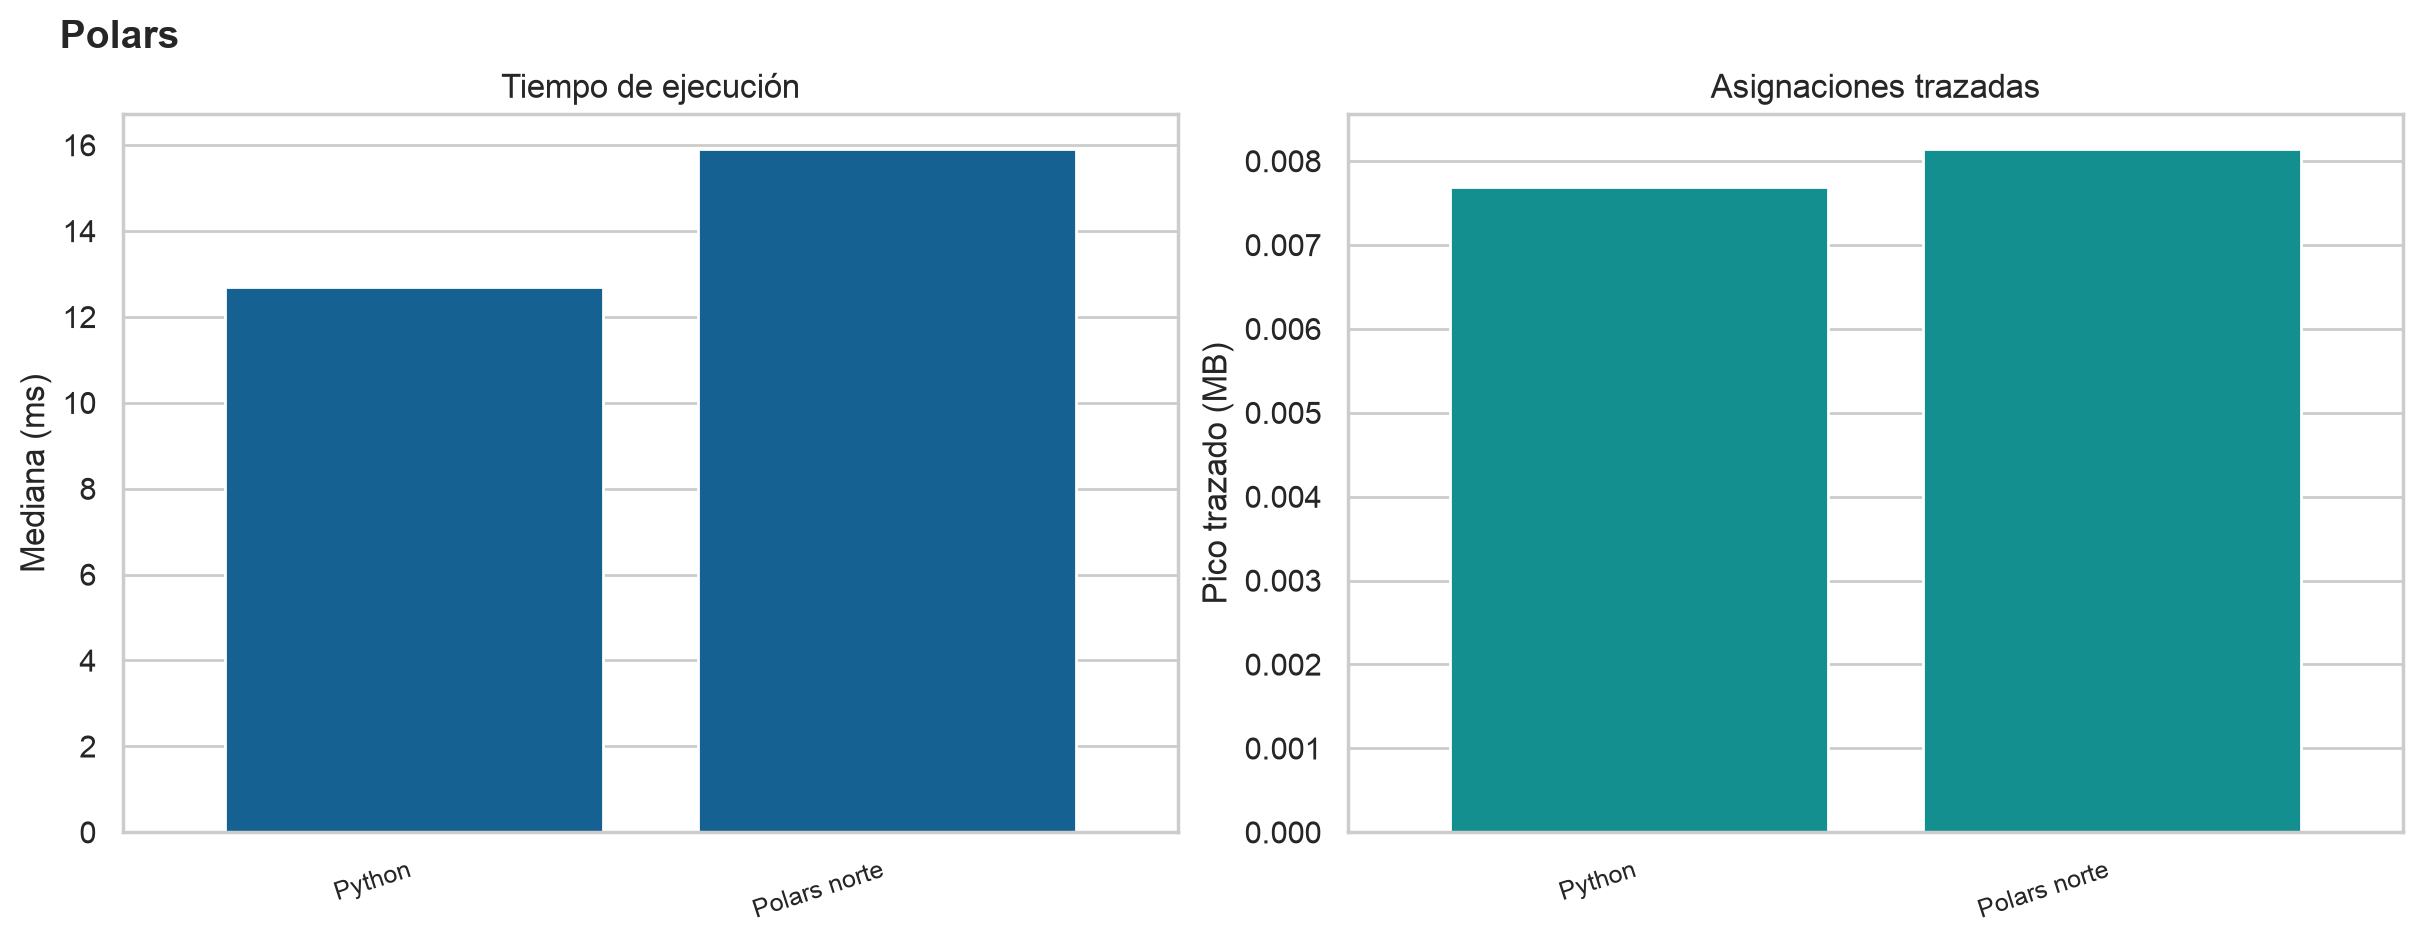

In [34]:
# Ejercicio 5
if POLARS_DISPONIBLE:
    plan_norte = (pl.scan_csv(RUTA_HISTORICO)
        .select(COLUMNAS)
        .filter((pl.col('estado') == 'confirmada') & (pl.col('region') == 'norte'))
        .with_columns([
            pl.col('fecha').str.strptime(pl.Date, strict=False).dt.strftime('%Y-%m').alias('mes'),
            (pl.col('importe') * pl.when(pl.col('canal') == 'app').then(0.999).otherwise(0.998)).alias('importe_neto'),
        ])
        .group_by(CLAVES)
        .agg([pl.col('importe_neto').sum().alias('importe_neto'), pl.len().alias('operaciones')])
        .sort(CLAVES))
    resultado_norte, medida_norte = medir('Polars norte', lambda: plan_norte.collect().to_pandas())
    salida_python, medida_python = medir('Python', lambda: plan_norte.collect().to_pandas())
    referencia_norte = referencia.loc[referencia['region'].eq('norte')].reset_index(drop=True)
    pd.testing.assert_frame_equal(referencia_norte, resultado_norte, check_dtype=False, check_exact=False, rtol=1e-10)
    print(plan_norte.explain(optimized=True))
    
    graficar_medidas([medida_python, medida_norte], 'Polars')

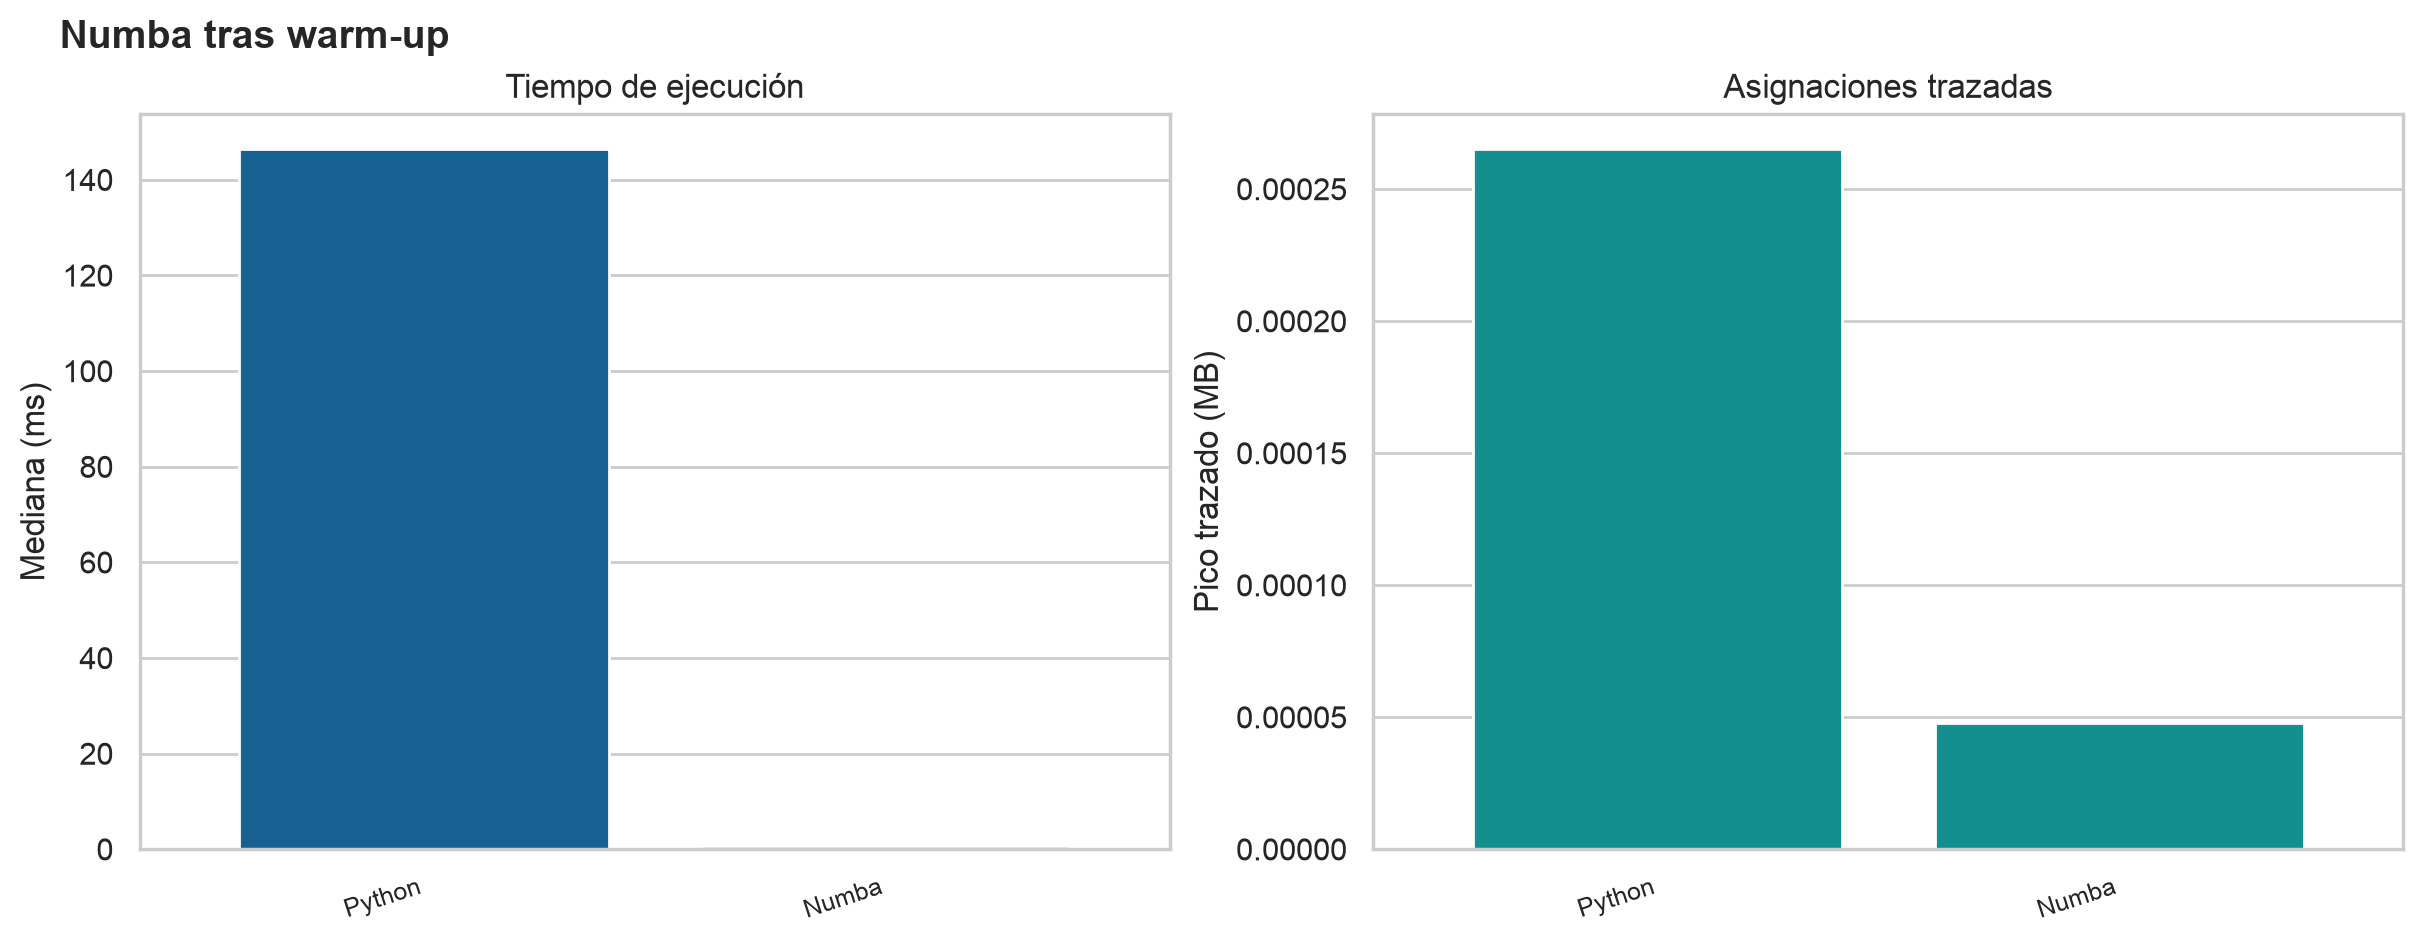

In [35]:
# Ejercicio 6
try:
    from numba import njit
    alertas_compilada = njit(alertas_python)
    _ = alertas_compilada(vector[:10])  # warm-up fuera de la comparación
    salida_numba, medida_numba = medir('Numba', lambda: alertas_compilada(vector))
    salida_python, medida_python = medir('Python', lambda: alertas_python(vector))
    assert salida_numba == salida_python
    graficar_medidas([medida_python, medida_numba], 'Numba tras warm-up')
except ImportError:
    print('Numba no está instalado.')

In [36]:
# Ejercicio 7
resultado_seq, medida_seq = medir('Secuencial', lambda: [consulta_simulada(i) for i in range(12)], repeticiones=2)
resultado_thr, medida_thr = medir('Threads', lambda: list(ThreadPoolExecutor(max_workers=4).map(consulta_simulada, range(12))), repeticiones=2)
assert resultado_seq == resultado_thr
speedup = medida_seq['mediana_ms'] / medida_thr['mediana_ms']
pd.DataFrame([medida_seq, medida_thr]).assign(speedup=[1.0, speedup])

,tecnica,mediana_ms,pico_trazado_mb,resultado_mb,speedup
0,Secuencial,292.892083,0.000440,NaN,1.000000
1,Threads,74.350271,0.037817,NaN,3.939355


## Preguntas abiertas

1. ¿Qué transformaciones de vuestro trabajo impedirían combinar resultados por bloques de forma exacta?
2. ¿Qué métrica adicional recogerías en producción además de tiempo y memoria?
3. ¿Qué coste de mantenimiento introduces al pasar de Pandas a Polars, Numba o procesos?
4. ¿Qué experimento diseñarías antes de afirmar que una librería es la opción adecuada para vuestro caso?